# Iris Dataset — Exploratory Data Analysis (EDA)
**Internship Task | AI/ML Engineer**  
*Dataset: Iris flower measurements — 150 samples, 4 features, 3 species*


In [1]:
import subprocess, sys
for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    print(f"  ✔ {pkg}")
print("\nAll libraries ready!")


  ✔ pandas
  ✔ numpy
  ✔ matplotlib
  ✔ seaborn
  ✔ scikit-learn

All libraries ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
print("Libraries loaded.")


Libraries loaded.


## 1. Load & Inspect the Dataset

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.to_csv('iris.csv', index=False)

print(f"Shape: {df.shape}")
print(f"Classes: {df['species'].unique().tolist()}")
df.head(10)


Shape: (150, 5)
Classes: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
print("Data Types")
print(df.dtypes)
print("\nMissing Values")
print(df.isnull().sum())
print("\nGood news: The Iris dataset is clean with NO missing values!")


Data Types
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Good news: The Iris dataset is clean with NO missing values!


In [5]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
# Species counts
print("Samples per species:")
print(df['species'].value_counts())
print("\nPerfectly balanced — 50 samples per species.")


Samples per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Perfectly balanced — 50 samples per species.


## 2. Data Overview
The Iris dataset is already clean — **no missing values, no duplicates, perfectly balanced classes** (50 per species).

**Feature engineering:** We'll add a `petal_area` and `sepal_area` derived feature.


In [7]:
# Feature engineering
df['petal_area'] = df['petal length (cm)'] * df['petal width (cm)']
df['sepal_area'] = df['sepal length (cm)'] * df['sepal width (cm)']

print("New features added: petal_area, sepal_area")
df[['species','petal_area','sepal_area']].groupby('species').mean().round(2)


New features added: petal_area, sepal_area


,petal_area,sepal_area
species,,
setosa,0.37,17.26
versicolor,5.72,16.53
virginica,11.30,19.68


## 3. Visualizations

### Fig 1 — Feature Pairplot

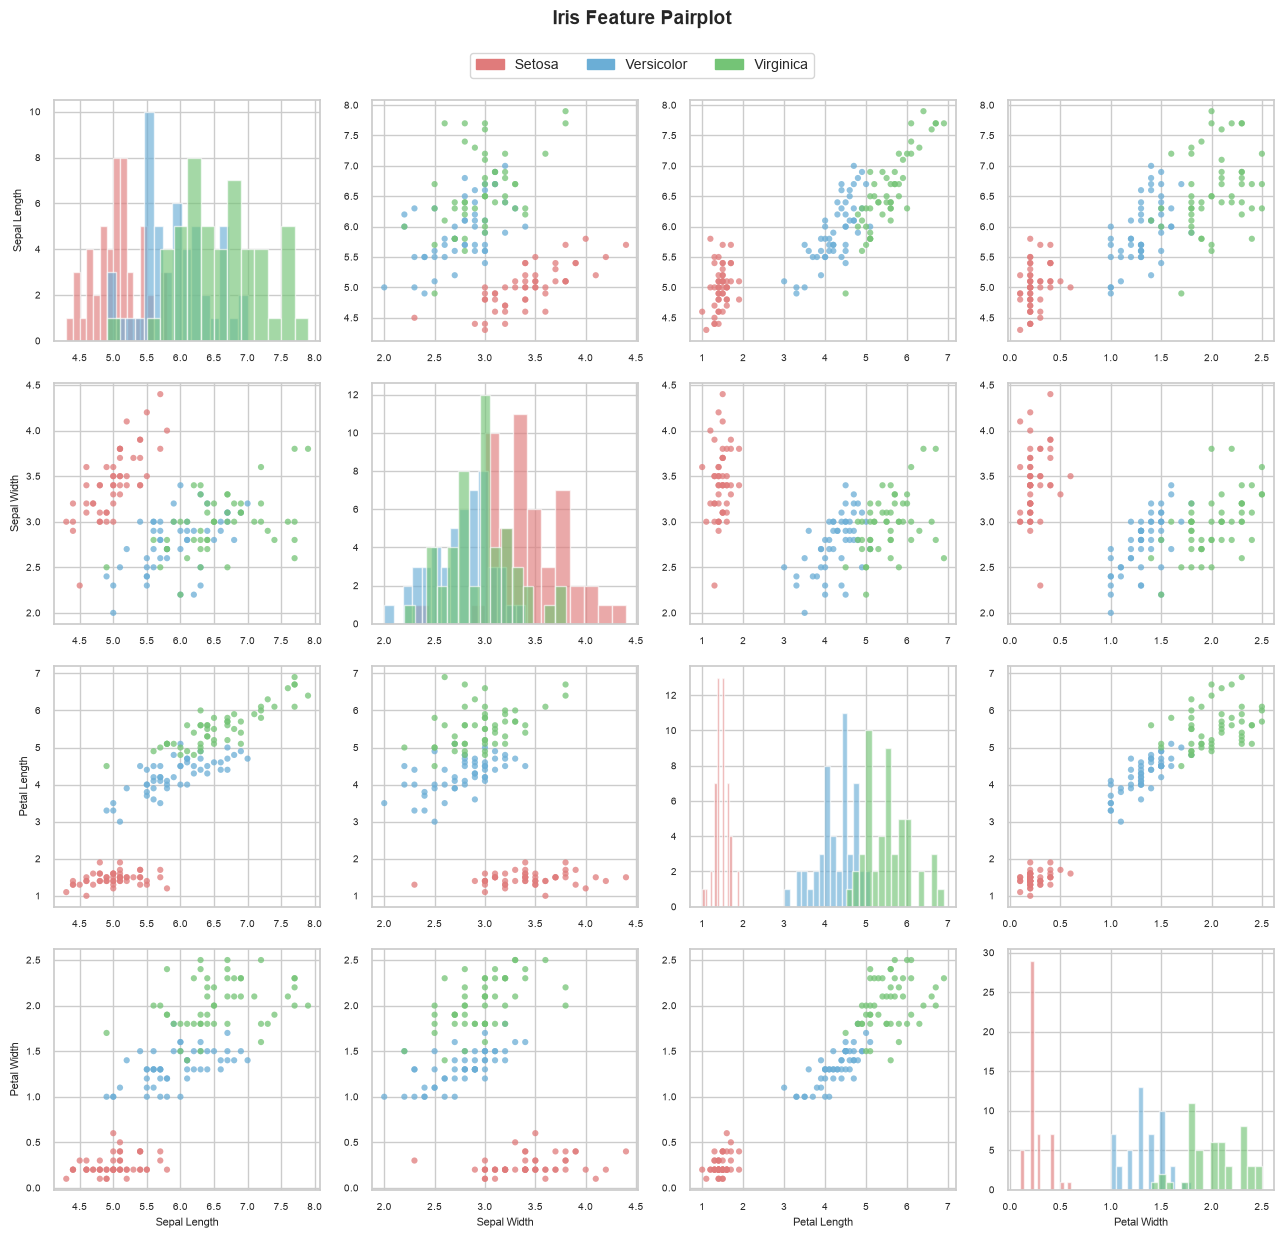

In [8]:
colors = {'setosa':'#e07b7b', 'versicolor':'#6baed6', 'virginica':'#74c476'}
species = ['setosa','versicolor','virginica']
features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']

fig, axes = plt.subplots(4, 4, figsize=(13, 12))
for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        ax = axes[i][j]
        if i == j:
            for sp in species:
                sub = df[df['species']==sp]
                ax.hist(sub[fi], bins=15, alpha=0.65, color=colors[sp], edgecolor='white')
        else:
            for sp in species:
                sub = df[df['species']==sp]
                ax.scatter(sub[fj], sub[fi], c=colors[sp], s=20, alpha=0.75, edgecolor='none')
        if i == 3: ax.set_xlabel(short[j], fontsize=8)
        if j == 0: ax.set_ylabel(short[i], fontsize=8)
        ax.tick_params(labelsize=7)

patches = [plt.matplotlib.patches.Patch(color=colors[sp], label=sp.capitalize()) for sp in species]
fig.legend(handles=patches, loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Iris Feature Pairplot", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig1_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


### Fig 2 — Box Plots by Species

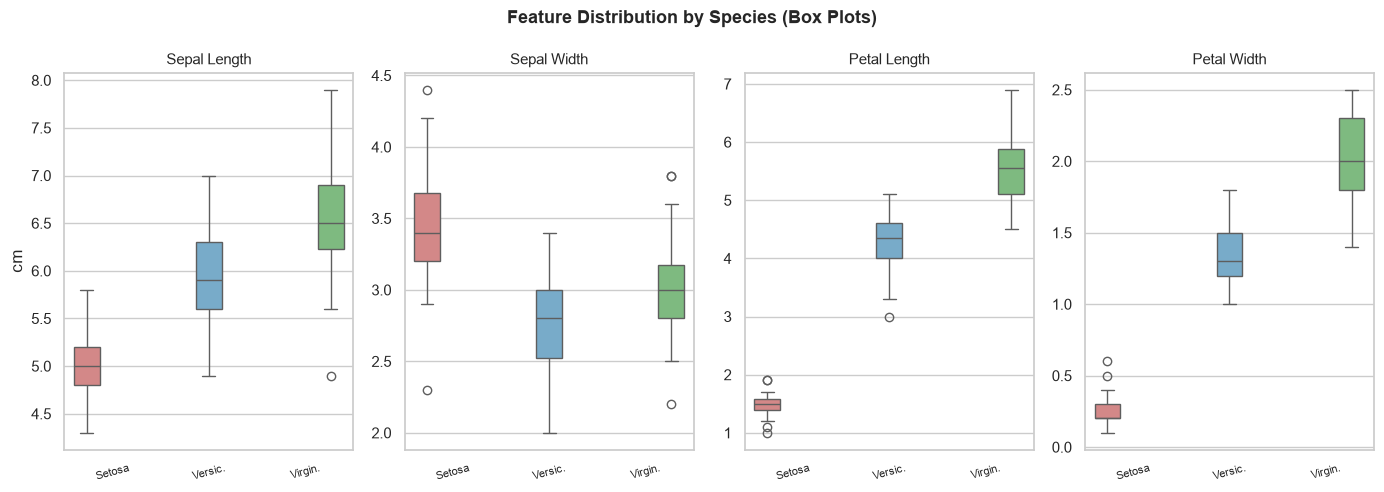

In [9]:
colors = {'setosa':'#e07b7b', 'versicolor':'#6baed6', 'virginica':'#74c476'}; features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']; short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Feature Distribution by Species (Box Plots)", fontsize=13, fontweight='bold')
for i, (feat, s) in enumerate(zip(features, short)):
    sns.boxplot(data=df, x='species', y=feat, hue='species', palette=colors, ax=axes[i], legend=False)
    axes[i].set_title(s, fontsize=11); axes[i].set_xlabel('')
    axes[i].set_ylabel('cm' if i==0 else '')
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(['Setosa','Versic.','Virgin.'], rotation=15, fontsize=8)
plt.tight_layout()
plt.savefig('fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### Fig 3 — Violin Plots by Species

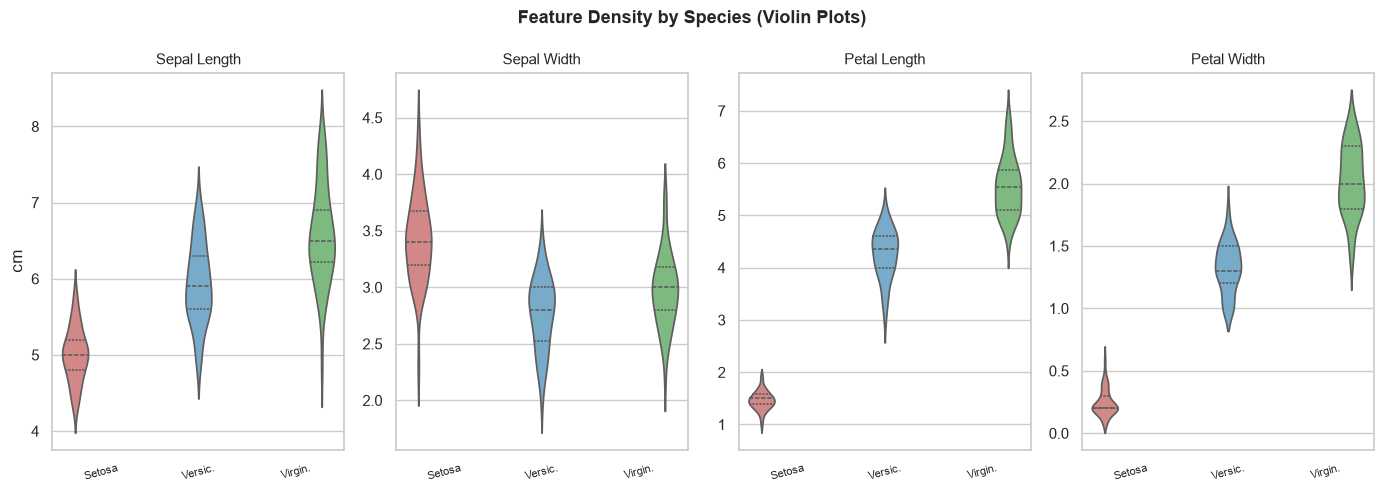

In [10]:
colors = {'setosa':'#e07b7b', 'versicolor':'#6baed6', 'virginica':'#74c476'}; features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']; short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Feature Density by Species (Violin Plots)", fontsize=13, fontweight='bold')
for i, (feat, s) in enumerate(zip(features, short)):
    sns.violinplot(data=df, x='species', y=feat, hue='species',
                   palette=colors, ax=axes[i], legend=False, inner='quartile')
    axes[i].set_title(s, fontsize=11); axes[i].set_xlabel('')
    axes[i].set_ylabel('cm' if i==0 else '')
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(['Setosa','Versic.','Virgin.'], rotation=15, fontsize=8)
plt.tight_layout()
plt.savefig('fig3_violinplots.png', dpi=150, bbox_inches='tight')
plt.show()


### Fig 4 — Correlation Heatmap

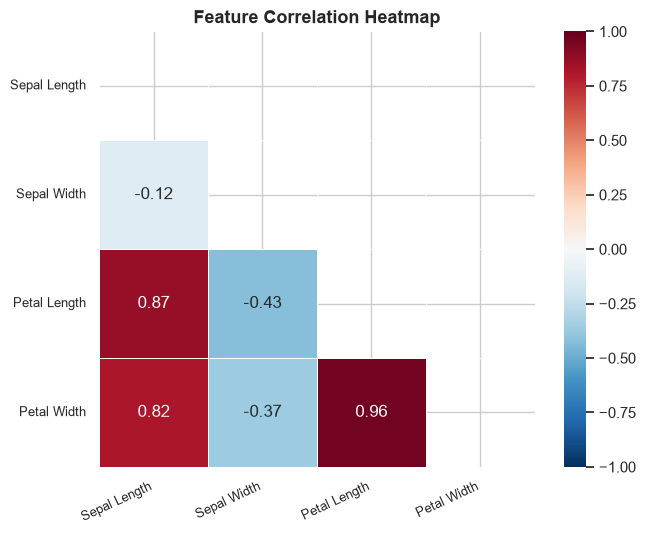

Key insight: Petal Length & Petal Width are highly correlated (r=0.96)
Sepal Width is weakly/negatively correlated with petal features


In [11]:
short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']
fig, ax = plt.subplots(figsize=(7, 5.5))
corr = df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={"size":12})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
ax.set_xticklabels(short, rotation=25, ha='right', fontsize=9)
ax.set_yticklabels(short, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: Petal Length & Petal Width are highly correlated (r=0.96)")
print("Sepal Width is weakly/negatively correlated with petal features")


### Fig 5 — Petal Length vs Petal Width (Best Separator)

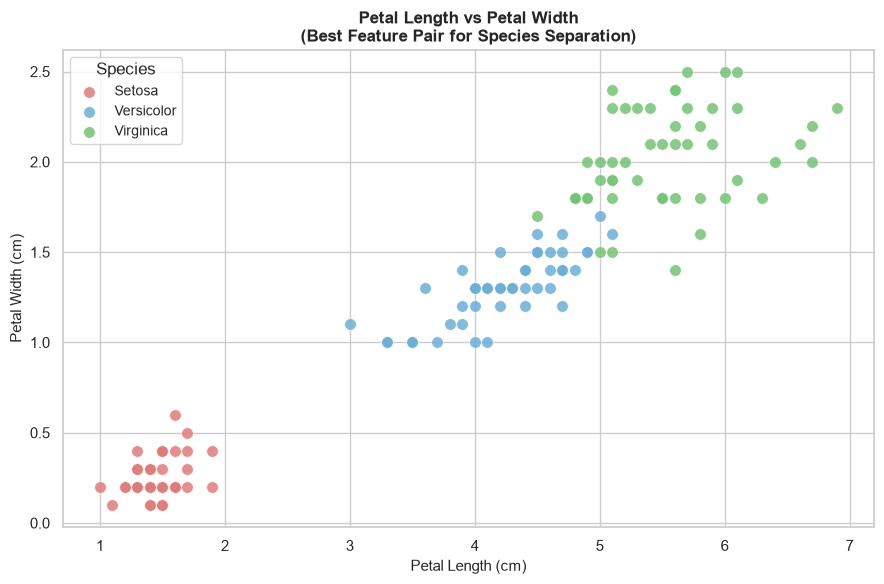

Setosa is perfectly linearly separable from the other two species!


In [12]:
colors = {'setosa':'#e07b7b', 'versicolor':'#6baed6', 'virginica':'#74c476'}; species = ['setosa','versicolor','virginica']
fig, ax = plt.subplots(figsize=(9, 6))
for sp in species:
    sub = df[df['species']==sp]
    ax.scatter(sub['petal length (cm)'], sub['petal width (cm)'],
               c=colors[sp], s=70, alpha=0.85, edgecolor='white', linewidth=0.5, label=sp.capitalize())
ax.set_xlabel("Petal Length (cm)", fontsize=11)
ax.set_ylabel("Petal Width (cm)", fontsize=11)
ax.set_title("Petal Length vs Petal Width\n(Best Feature Pair for Species Separation)", fontsize=12, fontweight='bold')
ax.legend(title='Species', fontsize=10)
plt.tight_layout()
plt.savefig('fig5_petal_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Setosa is perfectly linearly separable from the other two species!")


### Fig 6 — Mean Feature Values by Species

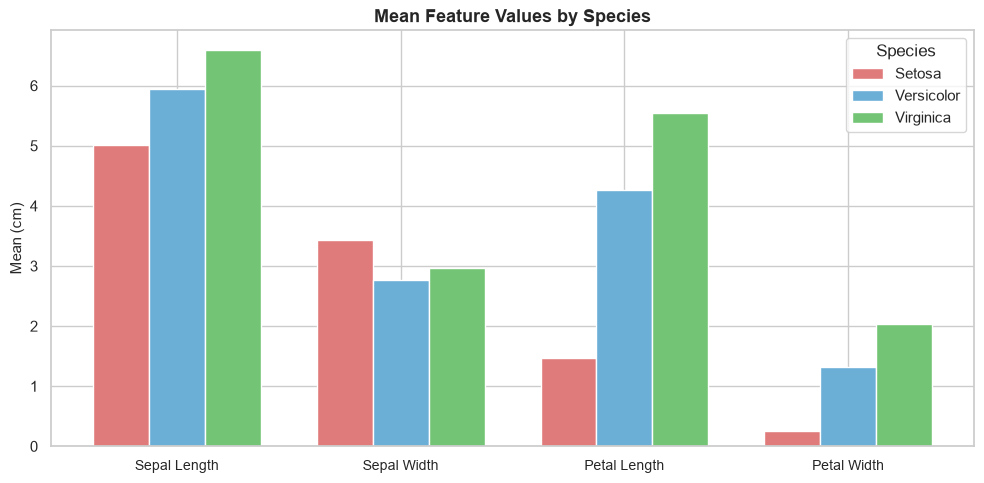

In [13]:
colors = {'setosa':'#e07b7b', 'versicolor':'#6baed6', 'virginica':'#74c476'}; species = ['setosa','versicolor','virginica']; features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']; short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']
fig, ax = plt.subplots(figsize=(10, 5))
means = df.groupby('species')[features].mean()
x = np.arange(4); w = 0.25
for idx, sp in enumerate(species):
    ax.bar(x + idx*w, means.loc[sp], w, label=sp.capitalize(), color=list(colors.values())[idx], edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels(short, fontsize=10)
ax.set_ylabel("Mean (cm)", fontsize=11)
ax.set_title("Mean Feature Values by Species", fontsize=13, fontweight='bold')
ax.legend(title='Species')
plt.tight_layout()
plt.savefig('fig6_mean_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Key Findings Summary

In [14]:
species = ['setosa','versicolor','virginica']; features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']; short = ['Sepal Length','Sepal Width','Petal Length','Petal Width']
print("=" * 55)
print("IRIS EDA — KEY STATISTICS")
print("=" * 55)
for sp in species:
    sub = df[df['species']==sp]
    print(f"\n{sp.upper()}:")
    for feat, s in zip(features, short):
        print(f"  {s}: {sub[feat].mean():.2f} ± {sub[feat].std():.2f} cm")

print("\nPetal Length & Petal Width correlation:", round(df['petal length (cm)'].corr(df['petal width (cm)']),2))
print("Sepal Width & Petal Length correlation:", round(df['sepal width (cm)'].corr(df['petal length (cm)']),2))


IRIS EDA — KEY STATISTICS

SETOSA:
  Sepal Length: 5.01 ± 0.35 cm
  Sepal Width: 3.43 ± 0.38 cm
  Petal Length: 1.46 ± 0.17 cm
  Petal Width: 0.25 ± 0.11 cm

VERSICOLOR:
  Sepal Length: 5.94 ± 0.52 cm
  Sepal Width: 2.77 ± 0.31 cm
  Petal Length: 4.26 ± 0.47 cm
  Petal Width: 1.33 ± 0.20 cm

VIRGINICA:
  Sepal Length: 6.59 ± 0.64 cm
  Sepal Width: 2.97 ± 0.32 cm
  Petal Length: 5.55 ± 0.55 cm
  Petal Width: 2.03 ± 0.27 cm

Petal Length & Petal Width correlation: 0.96
Sepal Width & Petal Length correlation: -0.43
